
# 02 — Comparison of Radiation Models

* MonopoleRadiation
* BaffledCircularPiston


In [2]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.append("..")

from src.components.driver import Driver
from src.components.enclosure import SealedBox
from src.components.radiation import MonopoleRadiation, BaffledCircularPiston
from src.system import LoudspeakerSystem
from src.diagrams.rendering import render_block_diagram
from src.utils import magnitude_to_db

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True



## Driver and simulation setup

All internal model parameters are expressed in SI units.

The driver parameters below are the values currently used for the Dayton driver model. The frequency grid extends from 10 Hz to 1 kHz; this notebook is focused on the low-frequency lumped-parameter regime rather than cone breakup or detailed high-frequency radiation.


In [3]:
# driver = Driver(
#     Re=3.4,          # ohm
#     Le=1.43e-3,      # H
#     Fs=35.7,         # Hz
#     Qms=6.62,
#     Qes=0.36,
#     Mms=39.5e-3,     # kg
#     Cms=0.5e-3,      # m/N
#     Sd=124.7e-4,     # m^2
#     Bl=9.15,         # T*m = N/A,
#     Xmax=6e-3        # mm
# )

driver = Driver.from_thiele_small(
    Re=3.4,
    Le=1.43e-3,

    Fs=35.7,
    Qms=6.620,
    Qes=0.360,

    Vas=12.10e-3,      # 12.10 L
    Sd=124.7e-4,       # 124.7 cm²

    Xmax=6e-3,         # 6 mm
    Pe=100,
)

freqs = np.logspace(1, 4, 1200)
voltage = 1.0

print(f"Fs (datasheet):              {driver.Fs:.2f} Hz")
print(f"Fs from Mms and Cms:         {driver.Fs_from_mass_compliance:.2f} Hz")
print(f"Qts:                         {driver.Qts:.3f}")
print(f"Rms:                         {driver.Rms:.3f} N·s/m")
print(f"Vas:                         {1e3 * driver.Vas():.2f} L")


Fs (datasheet):              35.70 Hz
Fs from Mms and Cms:         35.70 Hz
Qts:                         0.341
Rms:                         1.228 N·s/m
Vas:                         12.10 L



# Experiment 1 — Sealed box with monopole radiation

The third model uses exactly the same electromechanical sealed-box system and adds an **output radiation model**.

For the current half-space monopole approximation,

$p(r,\omega) = \frac{j\omega\rho_0 U}{2\pi r}e^{-jkr}$

At this stage radiation is **one-way**: cone volume velocity generates pressure, but radiation impedance is not fed back into the mechanical load.

That gives us an important regression test:

> adding `MonopoleRadiation` should create pressure, but should not change impedance, current, velocity, displacement, or volume velocity.


In [4]:

box = SealedBox(volume=3.68e-3)

monopole = MonopoleRadiation()

sealed_monopole = LoudspeakerSystem(
    driver=driver,
    enclosure=box,
    radiation=monopole,
)

mono_response = sealed_monopole.solve(
    freqs,
    voltage=voltage,
    distance=1.0,
)

mono_chars = sealed_monopole.characteristics()

print("SEALED + MONOPOLE CHARACTERISTICS")
print(f"Resonance frequency: {mono_chars.resonance_frequency:.2f} Hz")
print(f"Qtc:                 {mono_chars.total_q:.3f}")
print(f"Pressure available:  {mono_response.pressure is not None}")


SEALED + MONOPOLE CHARACTERISTICS
Resonance frequency: 73.93 Hz
Qtc:                 0.707
Pressure available:  True


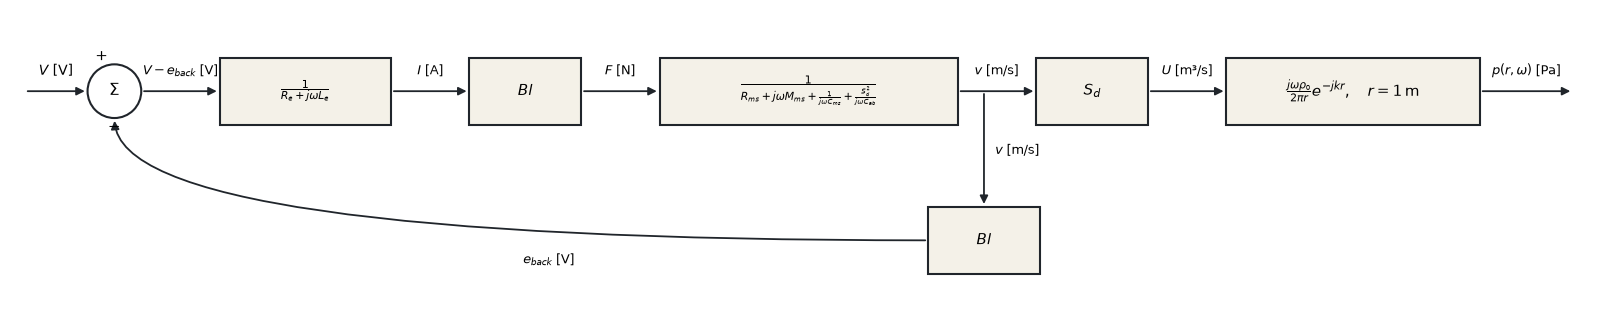

In [5]:
figure, _ = render_block_diagram(
        sealed_monopole.block_diagram(output='pressure', distance=1.0)
    )

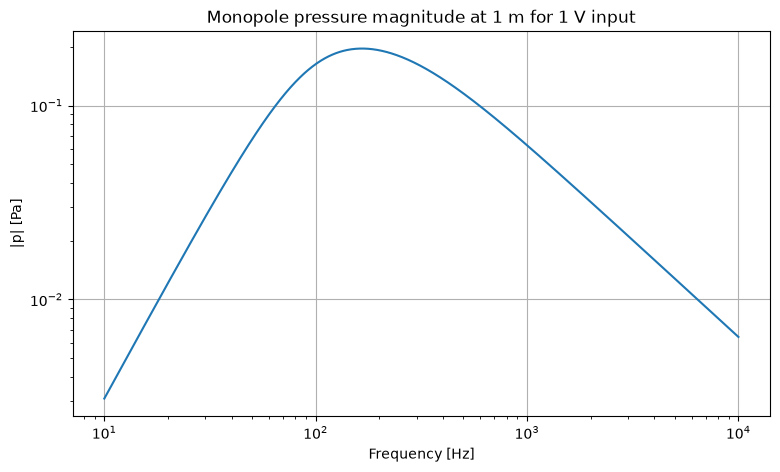

In [6]:

plt.figure()
plt.loglog(freqs, np.abs(mono_response.pressure))
plt.xlabel("Frequency [Hz]")
plt.ylabel("|p| [Pa]")
plt.title("Monopole pressure magnitude at 1 m for 1 V input")
plt.show()


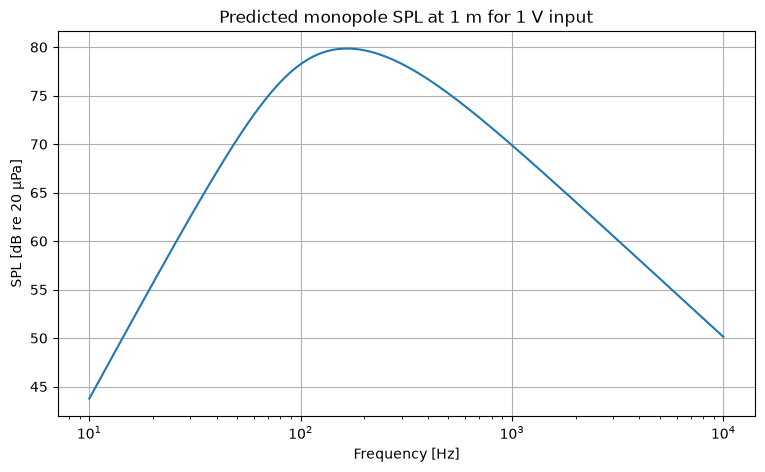

In [7]:

plt.figure()
plt.semilogx(freqs, mono_response.spl)
plt.xlabel("Frequency [Hz]")
plt.ylabel("SPL [dB re 20 µPa]")
plt.title("Predicted monopole SPL at 1 m for 1 V input")
plt.show()



Pressure is not proportional to displacement directly. The monopole model gives

$p \propto j\omega U$

so radiation contributes one additional factor of frequency. This is why a large low-frequency cone excursion does not necessarily imply a large radiated sound pressure.


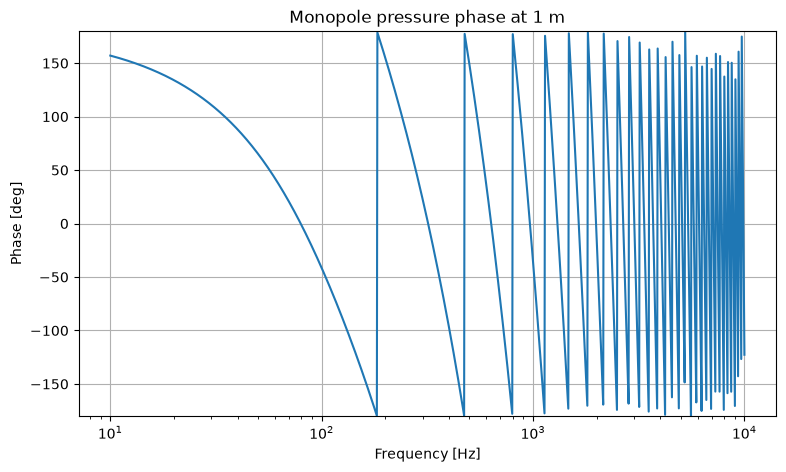

In [8]:

plt.figure()
plt.semilogx(freqs, np.angle(mono_response.pressure, deg=True))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Phase [deg]")
plt.ylim(-180, 180)
plt.title("Monopole pressure phase at 1 m")
plt.show()


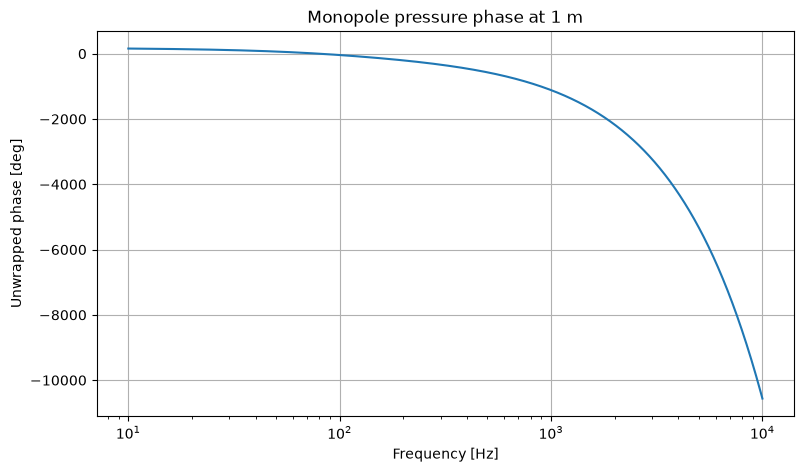

In [9]:
phase = np.unwrap(np.angle(mono_response.pressure))
phase_deg = np.degrees(phase)

plt.semilogx(freqs, phase_deg)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Unwrapped phase [deg]")
plt.title("Monopole pressure phase at 1 m")
plt.show()


The pressure phase contains both the source dynamics and the propagation phase term

$e^{-jkr}$

As distance or frequency increases, propagation delay contributes an increasingly large phase rotation.



# Experiment 2 — Sealed box with Baffled Circular Piston radiation

The fourth model uses exactly the same electromechanical sealed-box system and adds an improvement for the **output radiation model**.

The starting point is the Rayleigh integral for a baffled vibrating surface:

$p(\mathbf{x},\omega) =
\frac{j\rho_0\omega}{2\pi}
\int_S
v_n(\mathbf{y},\omega)
\frac{e^{-jkR}}{R}
\,dS
$

with

$R = |\mathbf{x}-\mathbf{y}|$

and

$ k=\frac{\omega}{c}$.

For this first version, the assumptions are:

- rigid circular piston
- uniform normal velocity over the piston
- infinite rigid baffle
- linear acoustics
- homogeneous medium
- no cone breakup
- no radiation loading fed back into mechanics yet

Just like the monopole model, this is still initially an output mapping

$v \rightarrow p$

rather than modifying the mechanical impedance.

The first simplification is that for a rigid piston,

$v_n(\mathbf y,\omega)=v(\omega)$

everywhere over the surface, so it comes outside the integral:

$p(\mathbf{x},\omega)=\frac{j\rho_0\omega v(\omega)}{2\pi}\int_S\frac{e^{-jkR}}{R},dS$

That is already nice because your current solver gives you exactly $v(\omega)$.
Then define the piston radius from the driver's effective area:

$\boxed{a=\sqrt{\frac{S_d}{\pi}}}$

For your driver, the piston becomes a disk of radius \(a\).
Now parameterize the source disk in polar coordinates:

$\mathbf y =(r'\cos\phi',\,r'\sin\phi',\,0)$

with

$0\le r'\le a$

and

$0\le\phi'<2\pi$.

The area element is

$dS=r'\,dr'\,d\phi'$.

If the receiver is at

$\mathbf x=(x_r,y_r,z_r)$,

then each infinitesimal piston element has distance

$R=\sqrt{(x_r-r'\cos\phi')^2 + (y_r-r'\sin\phi')^2 + z_r^2}.

So the pressure becomes the double integral

$\boxed{p(\mathbf x,\omega)=\frac{j\rho_0\omega v(\omega)}{2\pi}\int_0^a\int_0^{2\pi}\frac{e^{-jkR}}{R}r'\,d\phi'\,dr'}$

That is the equation our numerical model approximate.

Numerically, we divide the disk into little cells. For element \(i\),

$\Delta p_i=\frac{j\rho_0\omega}{2\pi}v\frac{e^{-jkR_i}}{R_i}\Delta S_i$.

Then sum:

$\boxed{p\approx\sum_i \Delta p_i}$


At this stage radiation is still **one-way**: cone volume velocity generates pressure, but radiation impedance is not fed back into the mechanical load.


In [11]:
piston = BaffledCircularPiston()

sealed_piston = LoudspeakerSystem(
    driver=driver,
    enclosure=box,
    radiation=piston,
)

piston_response = sealed_piston.solve(
    freqs,
    voltage=voltage,
    distance=1.0,
    angle=np.pi/4,
)

piston_chars = sealed_piston.characteristics()

print("SEALED + PISTON CHARACTERISTICS")
print(f"Resonance frequency: {piston_chars.resonance_frequency:.2f} Hz")
print(f"Qtc:                 {piston_chars.total_q:.3f}")
print(f"Pressure available:  {piston_response.pressure is not None}")


SEALED + PISTON CHARACTERISTICS
Resonance frequency: 73.93 Hz
Qtc:                 0.707
Pressure available:  True


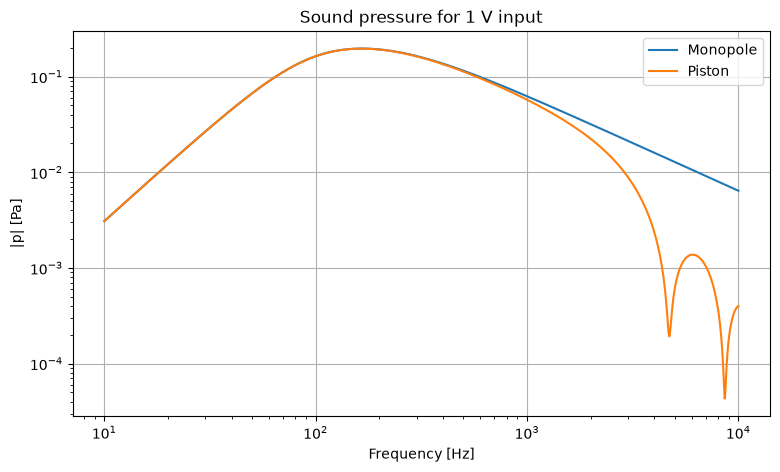

In [12]:
plt.figure()
plt.loglog(freqs, np.abs(mono_response.pressure), label="Monopole")
plt.loglog(freqs, np.abs(piston_response.pressure), label="Piston")

plt.xlabel("Frequency [Hz]")
plt.ylabel("|p| [Pa]")
plt.title("Sound pressure for 1 V input")
plt.legend()
plt.show()


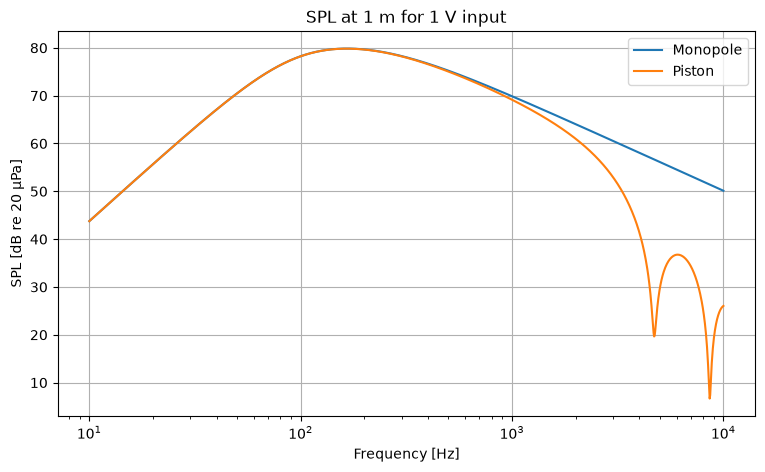

In [13]:
plt.figure()
plt.semilogx(freqs, np.abs(mono_response.spl), label="Monopole")
plt.semilogx(freqs, np.abs(piston_response.spl), label="Piston")

plt.xlabel("Frequency [Hz]")
plt.ylabel("SPL [dB re 20 µPa]")
plt.title("SPL at 1 m for 1 V input")
plt.legend()
plt.show()


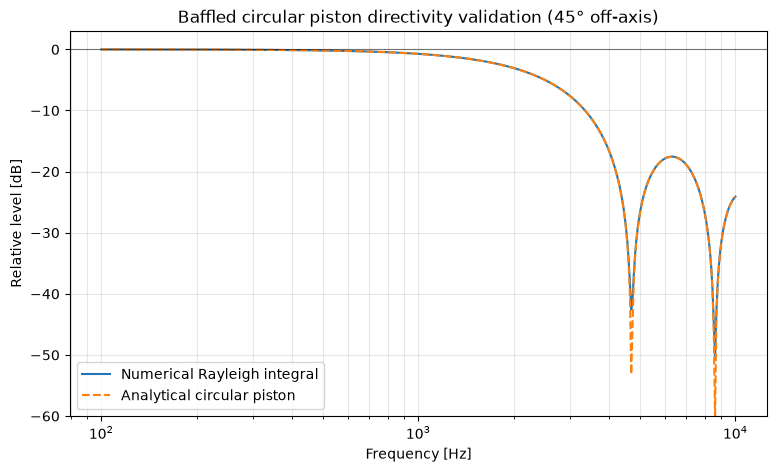

In [14]:
from scipy.special import j1
from src.constants import AIR

# ------------------------------------------------------------
# Validation setup
# ------------------------------------------------------------

angle_deg = 45.0
angle = np.deg2rad(angle_deg)

distance = 2.0  # m, reasonably far-field-ish for this driver

# Frequency range for validation
freq_test = np.logspace(
    np.log10(100),
    np.log10(10000),
    500
)

# ------------------------------------------------------------
# Driver / piston geometry
# ------------------------------------------------------------

Sd = driver.Sd
a = np.sqrt(Sd / np.pi)

c = AIR.speed_of_sound

omega = 2 * np.pi * freq_test
k = omega / c

# ------------------------------------------------------------
# Get cone velocity from the loudspeaker system
#
# Use the SAME electromechanical velocity for both on-axis
# and off-axis radiation calculations.
# ------------------------------------------------------------

response_test = sealed_monopole.solve(
    freq_test,
    voltage=1.0
)

velocity = response_test.velocity

# ------------------------------------------------------------
# Numerical Rayleigh-integral piston model
# ------------------------------------------------------------

piston = BaffledCircularPiston(
    n_radial=40,
    n_angular=80
)

p_on = piston.pressure(
    freq=freq_test,
    velocity=velocity,
    piston_area=Sd,
    distance=distance,
    angle=0.0,
    medium=AIR
)

p_off = piston.pressure(
    freq=freq_test,
    velocity=velocity,
    piston_area=Sd,
    distance=distance,
    angle=angle,
    medium=AIR
)

# Normalize numerical result to on-axis pressure
D_num = np.abs(p_off) / np.abs(p_on)

D_num_db = 20 * np.log10(
    np.maximum(D_num, 1e-12)
)

# ------------------------------------------------------------
# Analytical baffled circular piston directivity
#
# D(theta) = 2 J1(x) / x
#
# x = k a sin(theta)
# ------------------------------------------------------------

x = k * a * np.sin(angle)

D_analytical = np.ones_like(x)

mask = np.abs(x) > 1e-12

D_analytical[mask] = (
    2 * j1(x[mask])
    / x[mask]
)

D_analytical_db = 20 * np.log10(
    np.maximum(
        np.abs(D_analytical),
        1e-12
    )
)

# ------------------------------------------------------------
# Plot comparison
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.semilogx(
    freq_test,
    D_num_db,
    label="Numerical Rayleigh integral"
)

plt.semilogx(
    freq_test,
    D_analytical_db,
    "--",
    label="Analytical circular piston"
)

plt.axhline(
    0,
    color="black",
    linewidth=0.8,
    alpha=0.5
)

plt.xlabel("Frequency [Hz]")
plt.ylabel("Relative level [dB]")
plt.title(
    f"Baffled circular piston directivity validation "
    f"({angle_deg:.0f}° off-axis)"
)

plt.ylim(-60, 3)

plt.grid(
    True,
    which="both",
    alpha=0.3
)

plt.legend()

plt.show()